In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
df=pd.read_csv(r"C:\Users\theyc\OneDrive\Desktop\us honey analytics project\US_honey_dataset.csv")
print(df)

      Unnamed: 0         state  colonies_number  yield_per_colony  production  \
0              0       Alabama            16000                58      928000   
1              1       Arizona            52000                79     4108000   
2              2      Arkansas            50000                60     3000000   
3              3    California           420000                93    39060000   
4              4      Colorado            45000                60     2700000   
...          ...           ...              ...               ...         ...   
1110        1110      Virginia             6000                40       79000   
1111        1111    Washington            96000                32     1206000   
1112        1112  WestVirginia             6000                43      136000   
1113        1113     Wisconsin            42000                47      750000   
1114        1114       Wyoming            38000                58      242000   

       stocks  average_pric

In [4]:
df.head()

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


In [5]:
df.drop(columns = ["Unnamed: 0"], inplace = True)

In [6]:
df.head()

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


## WHAT EACH COLUMN IS ABOUT AND THEREFOR WHAT THIS WHOLE DATASET IS ABOUT

In [7]:
df.isnull().sum()

state                  0
colonies_number        0
yield_per_colony       0
production             0
stocks                 0
average_price          0
value_of_production    0
year                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
count,1115.000000,1115.000000,1.115000e+03,1.115000e+03,1115.000000,1.115000e+03,1115.000000
mean,62438.565022,59.743498,2.851268e+06,1.172625e+06,140.623076,5.667412e+06,2007.740807
std,92648.175955,19.940500,5.561202e+06,2.049556e+06,107.011544,9.459460e+06,7.823002
min,2000.000000,19.000000,1.200000e+04,9.000000e+03,1.300000,1.060000e+05,1995.000000
25%,9000.000000,45.000000,2.460000e+05,1.125000e+05,70.000000,1.008000e+06,2001.000000
50%,26000.000000,57.000000,8.280000e+05,3.700000e+05,128.000000,2.281000e+06,2008.000000
75%,69000.000000,71.000000,2.700000e+06,1.253500e+06,193.000000,5.704000e+06,2015.000000
max,550000.000000,155.000000,3.906000e+07,1.354500e+07,874.000000,8.385900e+07,2021.000000


In [10]:
df['year'].min()

np.int64(1995)

In [11]:
df['year'].max()

np.int64(2021)

In [12]:
df.head()

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


##  check if production is equal to total colonies* yeild per colony 

In [13]:
df['production'] == df['colonies_number'] * df['yield_per_colony']

0        True
1        True
2        True
3        True
4        True
        ...  
1110    False
1111    False
1112    False
1113    False
1114    False
Length: 1115, dtype: bool

In [15]:
## Which state is having the highest honey production through out all these years
pd.DataFrame(df.groupby('state')['production'].sum().sort_values(ascending=False))

,production
state,
NorthDakota,513742000
California,423876000
SouthDakota,355726000
Florida,280934000
Montana,197173000
Minnesota,176581000
Texas,129441000
Michigan,101063000
Wisconsin,99909000


In [17]:
## Which state is having the highest and the lowest yield per colony
df1 = pd.DataFrame(df.groupby('state')['yield_per_colony'].mean().sort_values(ascending=False))
df1

,yield_per_colony
state,
Hawaii,103.777778
Louisiana,92.814815
Mississippi,86.703704
NorthDakota,83.925926
Montana,79.555556
Florida,72.444444
SouthDakota,72.222222
Texas,71.148148
Wisconsin,70.222222


In [18]:
## Which year witnessed the highest profit in honey production
profit = df.groupby('year')['value_of_production'].sum().sort_values(ascending= False).reset_index()
profit

,year,value_of_production
0,2014,384483000
1,2016,335285000
2,2018,330766000
3,2017,326198000
4,2015,322505000
5,2013,315118000
6,2021,314413000
7,2019,303438000
8,2020,301831000
9,2012,280725000


In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
## Which state was having the highest stock in 2020
df3 = df[df['year']==2020]
df3.sort_values(by='stocks', ascending = False)

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
1065,SouthDakota,245000,61,8668000,8668000,1.77,26453000,2020
1060,NorthDakota,495000,78,8108000,8108000,1.59,61390000,2020
1055,Montana,110000,81,3208000,3208000,1.61,14345000,2020
1038,California,320000,43,2752000,2752000,1.95,26832000,2020
1052,Minnesota,108000,55,2495000,2495000,1.80,10692000,2020
1051,Michigan,95000,47,1384000,1384000,2.95,13172000,2020
1046,Iowa,35000,58,1259000,1259000,2.54,5156000,2020
1067,Texas,157000,57,1253000,1253000,2.00,17898000,2020
1062,Oregon,95000,29,1102000,1102000,2.40,6612000,2020
1040,Florida,192000,46,883000,883000,2.24,19784000,2020


In [21]:
## Which state is having the highest average price in the 21st century
df5 = df[df['year'] >2000]
avg_price = (df5.groupby('state')['average_price'].mean().sort_values(ascending=False).reset_index()
)
avg_price

,state,average_price
0,Virginia,270.651905
1,Nevada,254.333333
2,Illinois,244.401429
3,NorthCarolina,228.152857
4,NewJersey,227.987619
5,Kentucky,223.672500
6,Tennessee,215.002857
7,WestVirginia,210.533333
8,Vermont,198.926667
9,Maine,198.514286


In [22]:
## the trend how the production changes over time for the state Hawaii
hawaii_df = df[df["state"] == "Hawaii"]
hawaii_df

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
7,Hawaii,8000,129,1032000,103000,55.00,568000,1995
51,Hawaii,8000,155,1240000,62000,80.00,992000,1996
95,Hawaii,9000,146,1314000,158000,86.00,1130000,1997
138,Hawaii,8000,118,944000,66000,75.00,708000,1998
181,Hawaii,8000,80,640000,32000,78.00,499000,1999
224,Hawaii,7000,112,784000,125000,81.00,635000,2000
267,Hawaii,8000,87,696000,84000,85.00,592000,2001
310,Hawaii,7000,136,952000,29000,110.00,1047000,2002
354,Hawaii,7000,113,791000,43000,143.00,1131000,2003
398,Hawaii,8000,96,768000,77000,141.00,1083000,2004


In [23]:
## the 2 highest profitable states of all time on how was their change in yield_per colony
df.groupby('state')['value_of_production'].sum().sort_values(ascending = False)

state
NorthDakota      1186219000
California        653982000
SouthDakota       619095000
Florida           509670000
Montana           406563000
Minnesota         310462000
Texas             284720000
Michigan          217841000
NewYork           177921000
Wisconsin         176442000
Georgia           145945000
Idaho             139536000
Louisiana         129601000
Washington        119823000
Nebraska          106998000
Oregon            102109000
Iowa               87563000
Wyoming            87502000
Arkansas           73781000
Colorado           63844000
Arizona            59772000
Ohio               59637000
Mississippi        59265000
Pennsylvania       55153000
Hawaii             49888000
Utah               40157000
NorthCarolina      38645000
Illinois           36782000
Missouri           32372000
Alabama            28668000
NewJersey          28201000
Kansas             27970000
Tennessee          27276000
SouthCarolina      26218000
Indiana            24658000
Virginia      

In [24]:
df4 = df[(df['state']=='California') | (df['state']=='NorthDakota')]
df4

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
3,California,420000,93,39060000,4687000,60.00,23436000,1995
28,NorthDakota,220000,108,23760000,3802000,63.00,14969000,1995
47,California,390000,70,27300000,4641000,84.00,22932000,1996
72,NorthDakota,230000,86,19780000,4945000,90.00,17802000,1996
91,California,400000,75,30000000,9000000,70.00,21000000,1997
116,NorthDakota,245000,100,24500000,7350000,74.00,18130000,1997
134,California,450000,83,37350000,12326000,62.00,23157000,1998
159,NorthDakota,230000,128,29440000,8832000,63.00,18547000,1998
177,California,505000,60,30300000,10302000,53.00,16059000,1999
202,NorthDakota,255000,105,26775000,8836000,59.00,15797000,1999


## ANALYSIS WITH VISUALIZATION


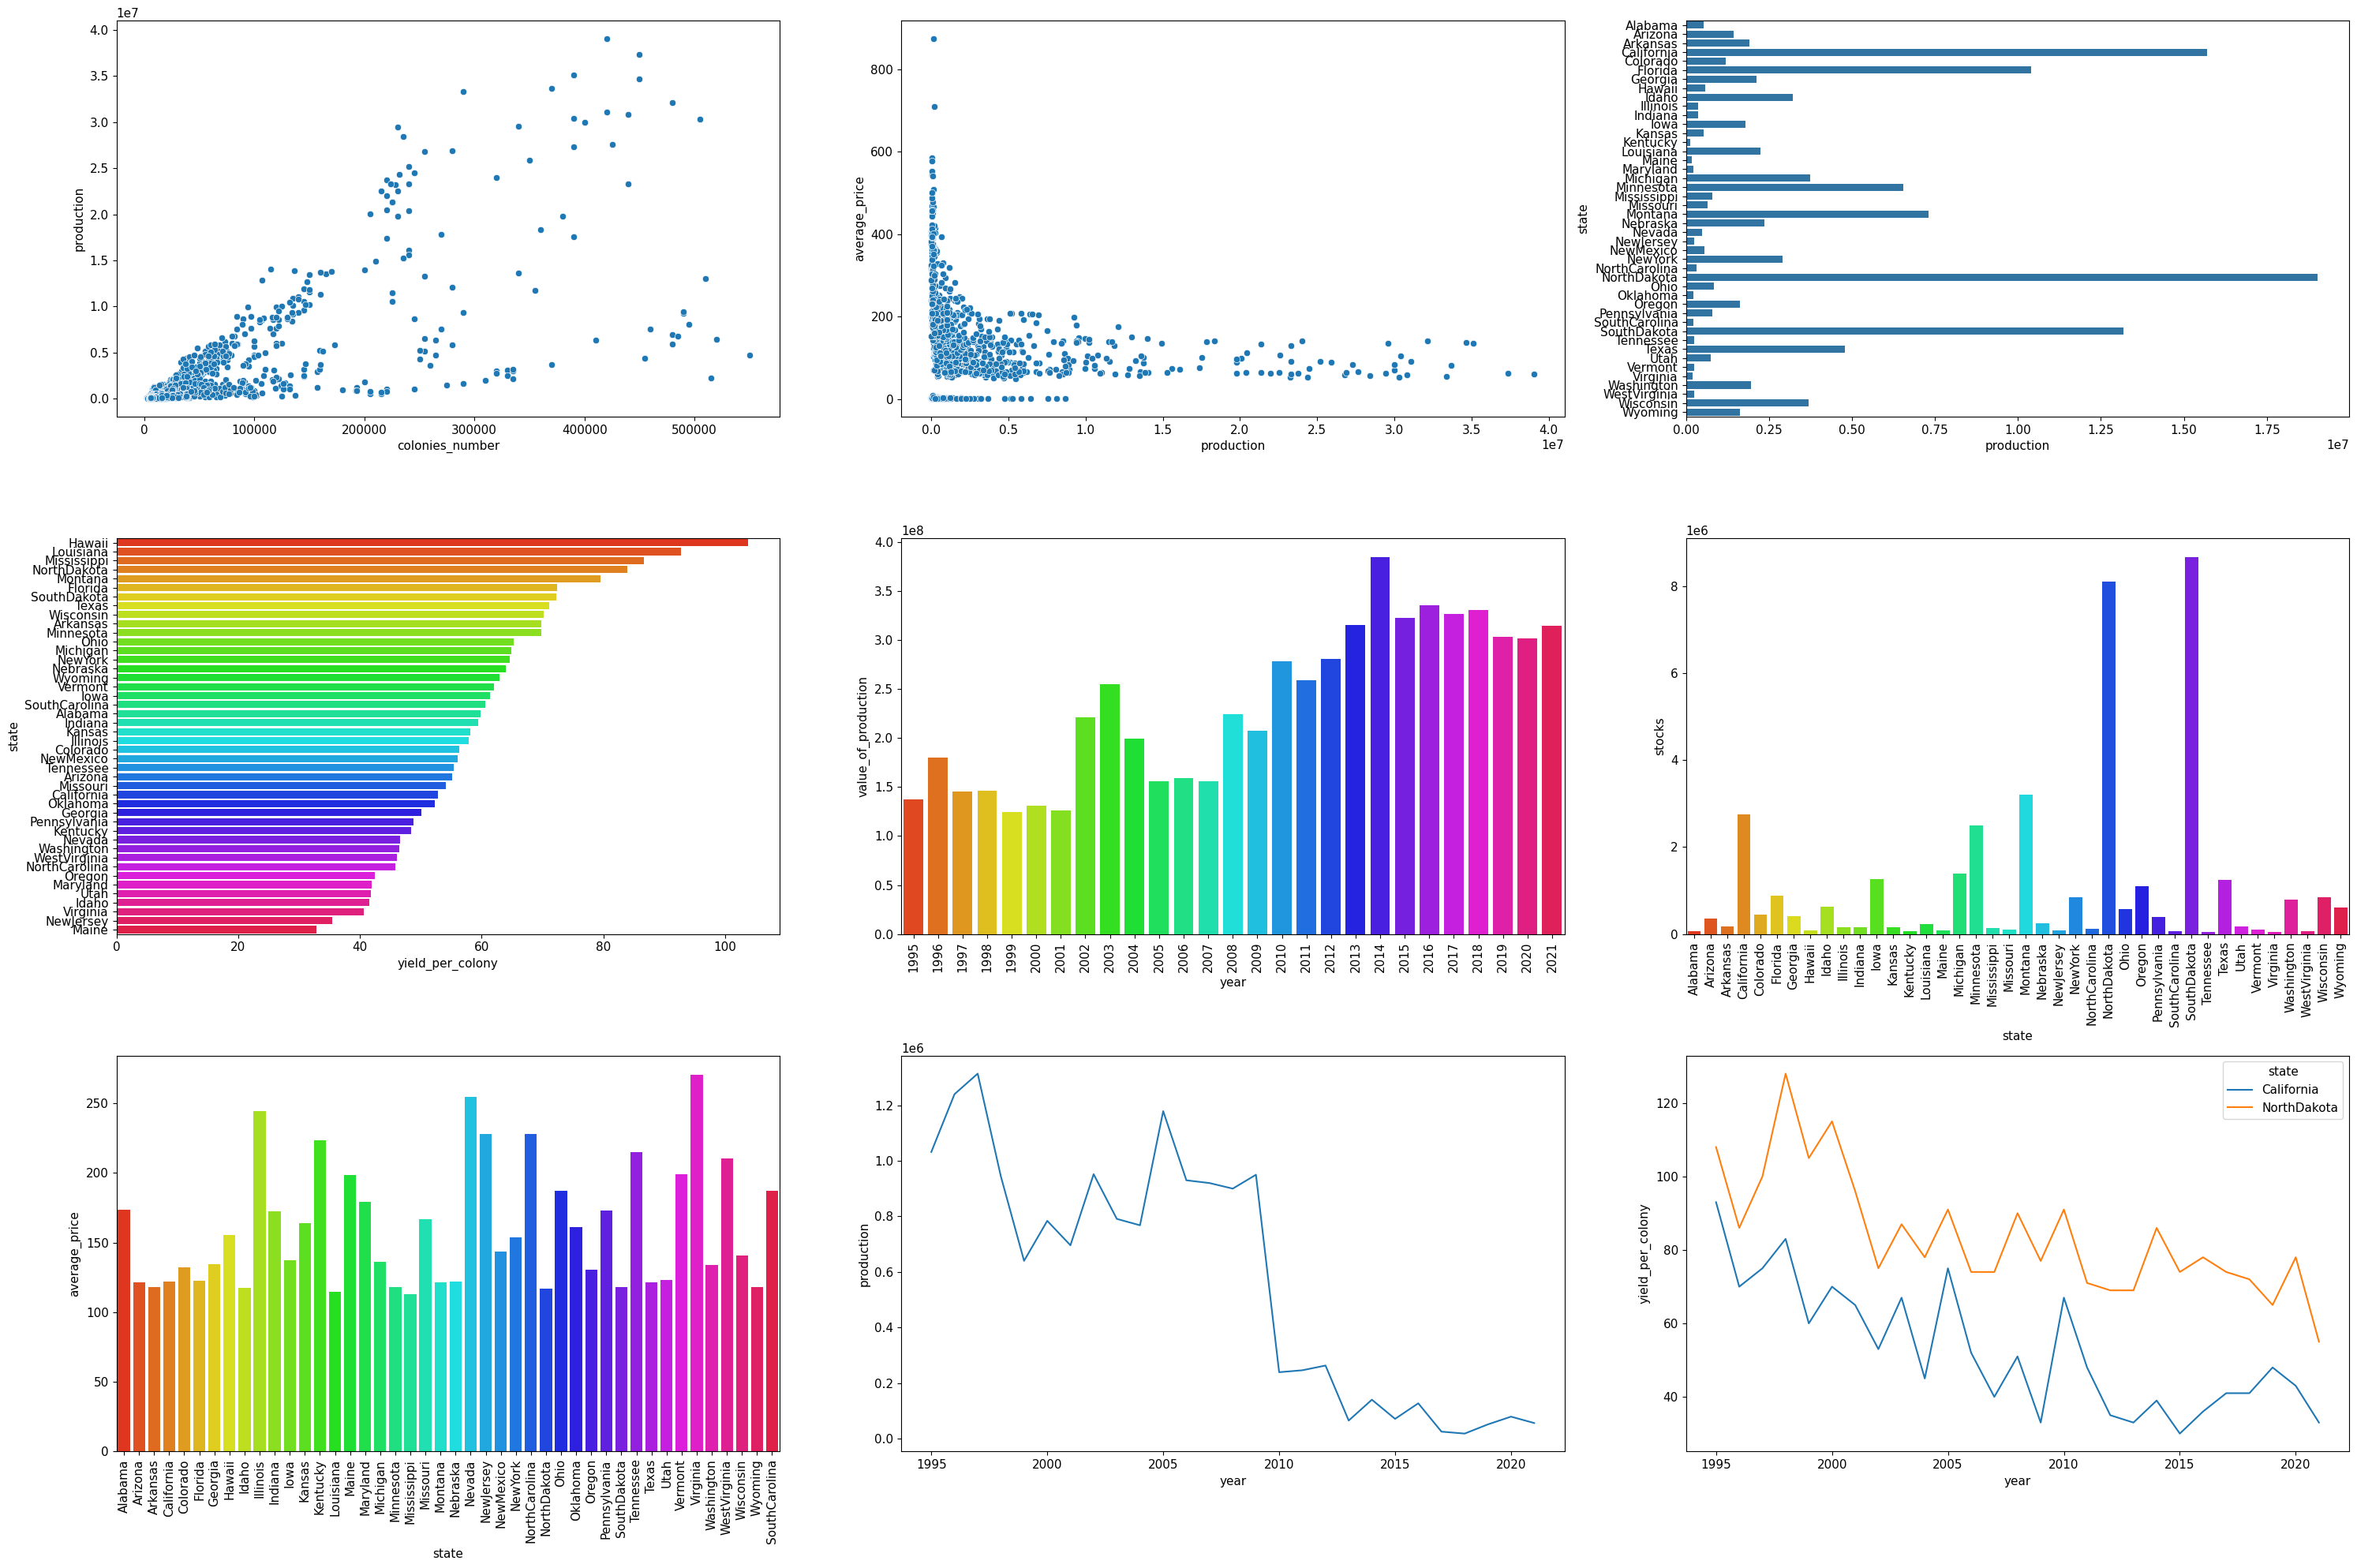

In [32]:
plt.figure(figsize=(30,20))
plt.rcParams['font.size'] = 11



#GRAPH1: relation between production and colonies number

plt.subplot(3,3,1)
sb.scatterplot(x='colonies_number',y='production',data=df)

#CONCLUSION:  # for most of the values if colonies increase the prodction value i.e how much honey is produced also increases
# but there are some such cases also where if the number of colonies is increasing still the honey produced stays less
# this indicates that the average honey produced must be very less in such data points



#GRAPH2: relationship between production and avg price

plt.subplot(3,3,2)
sb.scatterplot(y='average_price',x='production',data=df)

#CONCLUSION: When production is low the average price is high


#GRAPH3: Which state is having the highest honey production through out all these years

plt.subplot(3,3,3)
sb.barplot(x='production', y='state', data=df, errorbar=None)

#CONCLUSION:Highest honey production by state:
#North Dakota leads by a wide margin, followed by California and South Dakota. These are large agricultural states with ideal conditions for large-scale beekeeping.



#GRAPH4: Which state is having the highest and the lowest yield per colony

plt.subplot(3,3,4)
sb.barplot(x='yield_per_colony', y='state', data=df1, palette = 'hsv')

#CONCLUSION: Hawaii has the highest yield per colony (~104 lbs), likely due to its year-round warm climate allowing continuous foraging. Maine and New Jersey have the lowest (~33–35 lbs), as colder climates shorten the foraging season.



#GRAPH5: Which year witnessed the highest profit in honey production

plt.subplot(3,3,5)
sb.barplot(data = profit,x = 'year',y = 'value_of_production',palette = 'hsv')
plt.xticks(rotation = 90)

#CONCLUSION: 2014 was the most profitable year for honey production across the US, with total value of production peaking. The top 5 most profitable years all fall between 2014–2018, reflecting rising honey prices during that period.



#GRAPH6: Which state was having the highest stock in 2020

plt.subplot(3,3,6)
sb.barplot(data = df3, x ='state', y='stocks',palette='hsv')
plt.xticks(rotation=90)

#CONCLUSION: South Dakota held the highest honey stocks in 2020, followed closely by North Dakota and Montana — all major production states that stockpile large reserves.



#GRAPH7: Which state is having the highest average price in the 21st century

plt.subplot(3,3,7)
sb.barplot(data = df5, x ='state', y='average_price',palette='hsv', errorbar=None)
plt.xticks(rotation=90)

#CONCLUSION: Virginia had the highest average honey price, followed by Nevada and Illinois. Interestingly, these are not high-production states — lower supply in local markets likely drives the premium pricing.



#GRAPH8: the trend how the production changes over time for the state Hawaii

plt.subplot(3,3,8)
sb.lineplot(data = hawaii_df,x = 'year',y = 'production',palette = 'hsv')

#CONCLUSION: Hawaii's honey production was relatively stable through the late 1990s–2000s (~0.7M–1.3M lbs), but saw a dramatic and sustained decline from 2010 onwards, dropping to as low as 18,000 lbs in 2018. This could be linked to colony collapse disorder, habitat loss, or invasive species affecting Hawaiian bees.



#GRAPH9: the 2 highest profitable states of all time on how was their change in yield_per colony

plt.subplot(3,3,9)
sb.lineplot(data = df4,x ='year',y = 'yield_per_colony',hue = 'state')

#CONCLUSION: North Dakota consistently outperforms California in yield per colony. Both states show a gradual declining trend in yield per colony over recent years, which is concerning and likely reflects broader challenges like pesticide use and habitat degradation affecting bee health.



plt.tight_layout()
plt.show()





